# HAM10000 Dataset Exploration

HAM10000 is a large collection of dermoscopic skin lesion images.

This dataset is widely used for skin cancer classification and medical image analysis.

In this notebook, we will explore:

- Dataset files
- Metadata
- Skin lesion classes
- Class distribution
- Sample dermoscopic images

This notebook is part of my Medical AI learning journey and preparation for MobileSkinXAI.

In [1]:
import os
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image

## Step 1: Define Dataset Path

In Kaggle, datasets are stored inside the `/kaggle/input/` directory.

The HAM10000 dataset path used in this notebook is:

In [2]:
dataset_path = "/kaggle/input/datasets/kmader/skin-cancer-mnist-ham10000"

print("Dataset Path:", dataset_path)

Dataset Path: /kaggle/input/datasets/kmader/skin-cancer-mnist-ham10000


## Step 2: Check Dataset Files

Before loading the dataset, we should check what files and folders are available.

This helps us understand the dataset structure.

In [3]:
for item in os.listdir(dataset_path):
    print(item)

hmnist_8_8_RGB.csv
hmnist_28_28_RGB.csv
HAM10000_images_part_1
ham10000_images_part_1
hmnist_8_8_L.csv
HAM10000_images_part_2
ham10000_images_part_2
hmnist_28_28_L.csv
HAM10000_metadata.csv


## Step 3: Load Metadata

The file `HAM10000_metadata.csv` contains information about each skin lesion image.

Important columns include:

- image_id: image file name
- dx: diagnosis label
- age: patient age
- sex: patient sex
- localization: body location of the lesion

In [4]:
metadata_path = os.path.join(
    dataset_path,
    "HAM10000_metadata.csv"
)

df = pd.read_csv(metadata_path)

df.head()

,lesion_id,image_id,dx,dx_type,age,sex,localization
0,HAM_0000118,ISIC_0027419,bkl,histo,80.0,male,scalp
1,HAM_0000118,ISIC_0025030,bkl,histo,80.0,male,scalp
2,HAM_0002730,ISIC_0026769,bkl,histo,80.0,male,scalp
3,HAM_0002730,ISIC_0025661,bkl,histo,80.0,male,scalp
4,HAM_0001466,ISIC_0031633,bkl,histo,75.0,male,ear


## Step 4: Inspect Dataset Shape and Columns

The dataset shape tells us how many rows and columns are available.

Each row represents one skin lesion image.

In [5]:
print("Dataset Shape:", df.shape)

print("\nColumns:")
print(df.columns)

Dataset Shape: (10015, 7)

Columns:
Index(['lesion_id', 'image_id', 'dx', 'dx_type', 'age', 'sex', 'localization'], dtype='object')


## Step 5: Understand Lesion Classes

The `dx` column represents the diagnosis label.

Common HAM10000 labels include:

- nv: Melanocytic nevi
- mel: Melanoma
- bkl: Benign keratosis-like lesions
- bcc: Basal cell carcinoma
- akiec: Actinic keratoses and intraepithelial carcinoma
- vasc: Vascular lesions
- df: Dermatofibroma

In [6]:
df["dx"].value_counts()

dx
nv       6705
mel      1113
bkl      1099
bcc       514
akiec     327
vasc      142
df        115
Name: count, dtype: int64

## Step 6: Visualize Class Distribution

Class distribution shows how many images exist for each lesion type.

This is important because medical datasets are often imbalanced.

If one class has many more images than others, the model may become biased toward the majority class.

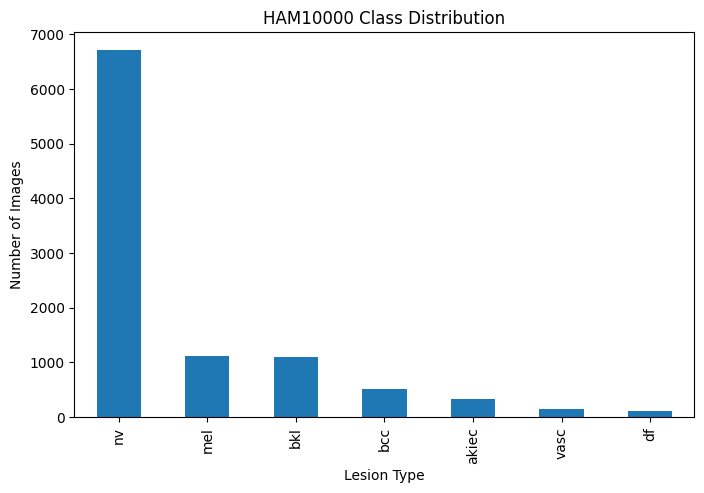

In [7]:
plt.figure(figsize=(8, 5))

df["dx"].value_counts().plot(kind="bar")

plt.title("HAM10000 Class Distribution")
plt.xlabel("Lesion Type")
plt.ylabel("Number of Images")

plt.show()

## Step 7: Define Image Folder Paths

The actual image files are stored in two folders:

- HAM10000_images_part_1
- HAM10000_images_part_2

We define both folders so that Python can search for each image.

In [8]:
image_folders = [
    os.path.join(dataset_path, "HAM10000_images_part_1"),
    os.path.join(dataset_path, "HAM10000_images_part_2")
]

for folder in image_folders:
    print(folder)

/kaggle/input/datasets/kmader/skin-cancer-mnist-ham10000/HAM10000_images_part_1
/kaggle/input/datasets/kmader/skin-cancer-mnist-ham10000/HAM10000_images_part_2


## Step 8: Create a Function to Find Image Paths

The metadata contains image IDs, but the images are stored as `.jpg` files.

This function searches both image folders and returns the correct image path.

In [9]:
def find_image_path(image_id):
    filename = image_id + ".jpg"

    for folder in image_folders:
        path = os.path.join(folder, filename)

        if os.path.exists(path):
            return path

    return None

## Step 9: Test Image Path Function

Before displaying images, we should test whether the function can correctly find an image file.

In [10]:
sample_image_id = df.iloc[0]["image_id"]

sample_image_path = find_image_path(sample_image_id)

print("Image ID:", sample_image_id)
print("Image Path:", sample_image_path)

Image ID: ISIC_0027419
Image Path: /kaggle/input/datasets/kmader/skin-cancer-mnist-ham10000/HAM10000_images_part_1/ISIC_0027419.jpg


## Step 10: Display One Sample Image

Now we display one dermoscopic skin lesion image from the dataset.

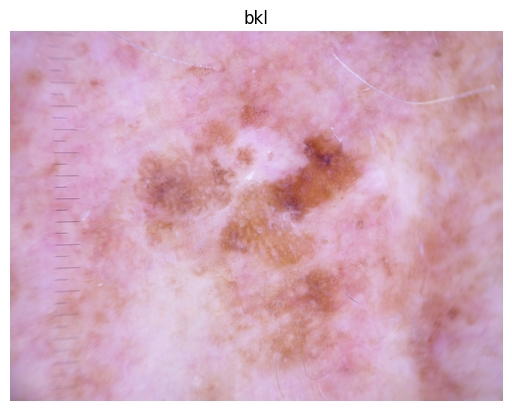

In [11]:
sample_image = Image.open(sample_image_path)

plt.imshow(sample_image)
plt.title(df.iloc[0]["dx"])
plt.axis("off")

plt.show()

## Step 11: Display Multiple Sample Images

Visualizing multiple images helps us understand how different lesion types look.

This is an important first step before preprocessing and model training.

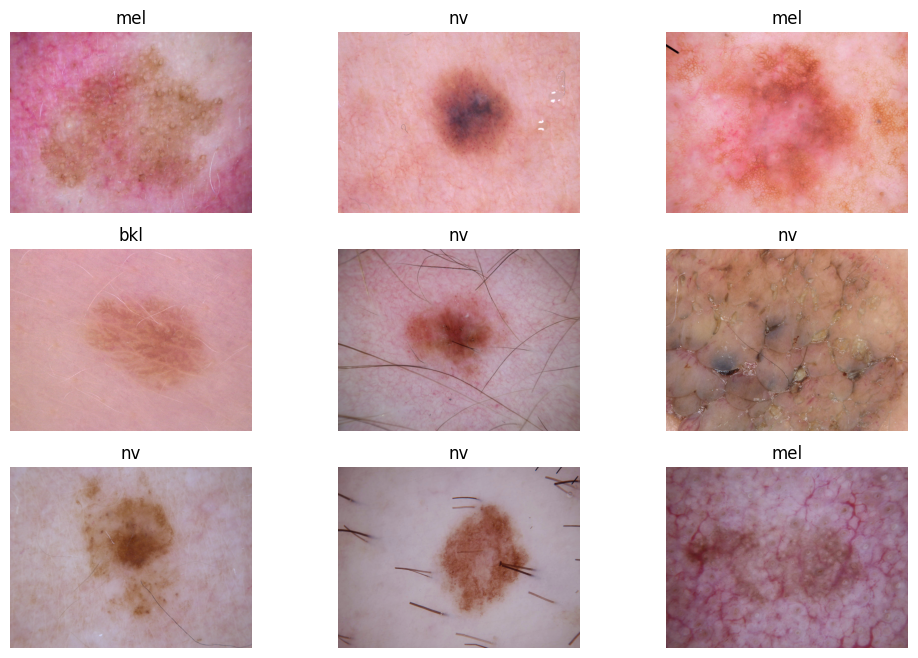

In [12]:
plt.figure(figsize=(12, 8))

sample_df = df.sample(9, random_state=42)

for i, (_, row) in enumerate(sample_df.iterrows()):
    image_path = find_image_path(row["image_id"])
    image = Image.open(image_path)

    plt.subplot(3, 3, i + 1)
    plt.imshow(image)
    plt.title(row["dx"])
    plt.axis("off")

plt.show()

## Step 12: Check Patient Age Distribution

The metadata also contains patient age.

Understanding age distribution can help us analyze dataset characteristics.

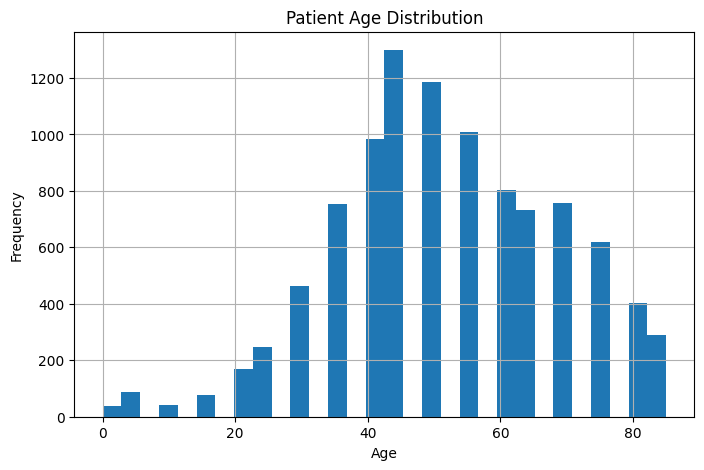

In [13]:
plt.figure(figsize=(8, 5))

df["age"].dropna().hist(bins=30)

plt.title("Patient Age Distribution")
plt.xlabel("Age")
plt.ylabel("Frequency")

plt.show()

## Step 13: Check Lesion Localization

The `localization` column shows where the lesion appears on the body.

This may be useful for medical analysis and future research.

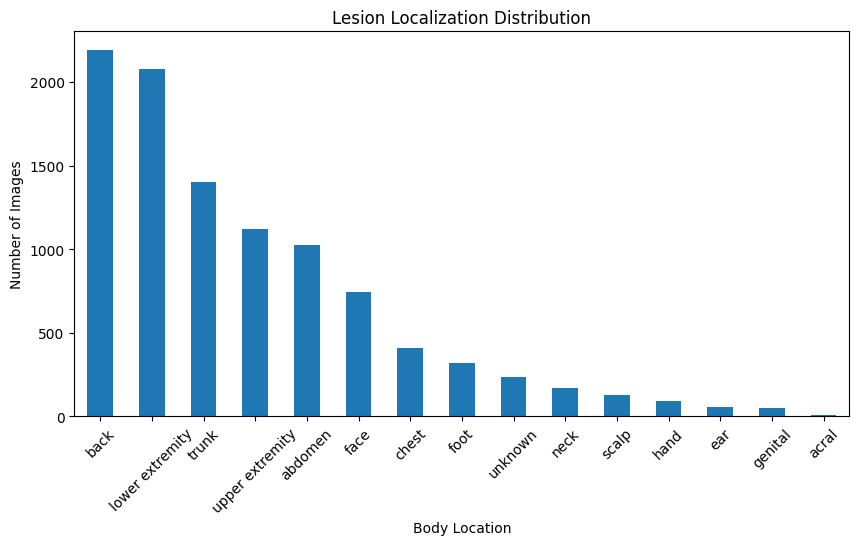

In [14]:
plt.figure(figsize=(10, 5))

df["localization"].value_counts().plot(kind="bar")

plt.title("Lesion Localization Distribution")
plt.xlabel("Body Location")
plt.ylabel("Number of Images")

plt.xticks(rotation=45)

plt.show()

# Summary

In this notebook, I explored the HAM10000 skin lesion dataset.

## What I Learned

- How to load medical image metadata
- How to inspect dataset files and folders
- How to analyze skin lesion class distribution
- How to find image paths from image IDs
- How to visualize real dermoscopic skin lesion images
- Why class imbalance matters in Medical AI
- How metadata such as age and lesion location can support analysis

This dataset exploration is the first step toward building a skin lesion classification model for MobileSkinXAI.